In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sunraster.instr.spice import read_spice_l2_fits
import h5py
import sunpy 
import sunpy.map
from sharpesst.correct_2d_psf import get_fwd_matrices, correct_spice_raster
from sharpesst.util import bindown, as_dict, get_iris_data, masked_median_filter, get_mask_errs
from sharpesst.fit_spice_lines import get_overall_center, fit_spice_lines as fsl
import astropy
from astropy.visualization import (ImageNormalize, AsinhStretch)
from astropy import constants as const
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
import juanfit
import importlib
importlib.reload(juanfit)
from juanfit import SpectrumFit2D, gaussian, SpectrumFitSingle, SpectrumFitRow
from scipy.signal import find_peaks
from sospice import spice_error
from scipy.optimize import curve_fit
import os
import itertools
from concurrent.futures import ProcessPoolExecutor
import concurrent
import concurrent.futures
import logging
from matplotlib.patches import Rectangle

from copy import deepcopy
from glob import glob

In [2]:
spice_raster = read_spice_l2_fits("../src/solo_L2_spice-n-ras_20221024T231535_V07_150995398-000.fits")

keyword looks very much like CROTAn but isn't. [astropy.wcs.wcs]
2025-03-04 16:12:14 - astropy - WARNING: FITSFixedWarning: CROTA = 4.69506977124 / [deg] S/C counter-clockwise roll rel to Solar N
keyword looks very much like CROTAn but isn't.
Set MJD-OBS to 59876.969164 from DATE-OBS.
Set MJD-BEG to 59876.969164 from DATE-BEG.
Set MJD-AVG to 59877.036108 from DATE-AVG.
Set MJD-END to 59877.103050 from DATE-END'. [astropy.wcs.wcs]
2025-03-04 16:12:14 - astropy - WARNING: FITSFixedWarning: 'datfix' made the change 'Set MJDREF to 59876.969164 from DATEREF.
Set MJD-OBS to 59876.969164 from DATE-OBS.
Set MJD-BEG to 59876.969164 from DATE-BEG.
Set MJD-AVG to 59877.036108 from DATE-AVG.
Set MJD-END to 59877.103050 from DATE-END'.
2025-03-04 16:12:14 - astropy - WARNING: UnitsWarning: 'W/m2/sr/nm' contains multiple slashes, which is discouraged by the FITS standard


In [3]:
spice_NeVIII_770_window = spice_raster["Ne VIII 770 - Peak"]

In [159]:
spice_NeVIII_data[spice_NeVIII_data > np.nanpercentile(spice_NeVIII_data, 16, axis=0)[np.newaxis,:,:]]

/cluster/software/stacks/2024-05/python-cuda/3.11.6/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, Fal

In [179]:
spice_NeVIII_data = spice_NeVIII_770_window.data[0].copy()
spice_NeVIII_data[spice_NeVIII_data < 0] = np.nan
spice_window_mask = np.isfinite(spice_NeVIII_data[:,120:700,:]).any(axis=(1,2))
spice_NeVIII_wvl = spice_NeVIII_770_window.spectral_axis.to_value(u.AA)[spice_window_mask]

start_wvl_index, end_wvl_index = np.where(spice_window_mask == True)[0][np.r_[0,-1]]

spice_NeVIII_header = spice_NeVIII_770_window.meta.original_header.copy()
spice_NeVIII_header_new_naxis3 = np.sum(spice_window_mask)
spice_NeVIII_header_new_crpix3 = (1 + spice_NeVIII_header_new_naxis3)/2.
spice_NeVIII_header_new_crval3 = ((start_wvl_index + end_wvl_index)/2. + 1 - spice_NeVIII_header['CRPIX3'])*spice_NeVIII_header['CDELT3'] + \
                                 spice_NeVIII_header['CRVAL3']

spice_NeVIII_header["NAXIS3"] = spice_NeVIII_header_new_naxis3
spice_NeVIII_header["CRPIX3"] = spice_NeVIII_header_new_crpix3
spice_NeVIII_header["CRVAL3"] = spice_NeVIII_header_new_crval3


spice_NeVIII_data_bg = deepcopy(spice_NeVIII_data)
spice_NeVIII_data_bg[spice_NeVIII_data_bg > np.nanpercentile(spice_NeVIII_data, 16, axis=0)[np.newaxis,:,:]] = np.nan
spice_NeVIII_data_bg = np.nanmedian(spice_NeVIII_data_bg, axis=0)

spice_NeVIII_data_bg_rm = spice_NeVIII_data - spice_NeVIII_data_bg[np.newaxis,:,:] #np.nanmin(spice_NeVIII_data, axis=0)[np.newaxis,:,:]
spice_NeVIII_data_bg_rm = spice_NeVIII_data_bg_rm[spice_window_mask,120:700,:]

rebin_facs = [1,2,1]
plot_aspect = spice_NeVIII_header['CDELT2']/spice_NeVIII_header['CDELT1']*rebin_facs[1]/rebin_facs[2]

spice_NeVIII_data_bin = bindown(spice_NeVIII_data_bg_rm,np.round(np.array(spice_NeVIII_data_bg_rm.shape)/rebin_facs).astype(np.int32))
spice_NeVIII_window_start = np.argmax(np.isfinite(spice_NeVIII_data_bin), axis=0)
spice_NeVIII_window_end = spice_NeVIII_data_bin.shape[0] - 1 - np.argmax(np.isfinite(spice_NeVIII_data_bin[::-1,:,:]), axis=0)

/cluster/software/stacks/2024-05/python-cuda/3.11.6/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
/scratch/tmp.25099103.zhuyin/ipykernel_702647/3158842999.py:21: RuntimeWarning: All-NaN slice encountered
  spice_NeVIII_data_bg = np.nanmedian(spice_NeVIII_data_bg, axis=0)


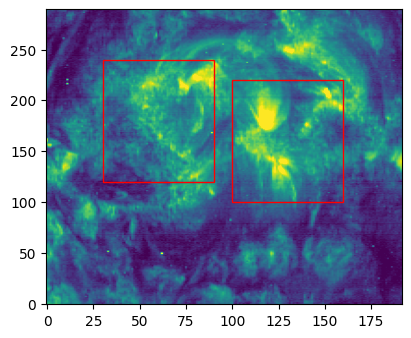

In [161]:
fig, ax = plt.subplots(figsize=(4,6), layout="constrained")
ax.imshow(np.nansum(spice_NeVIII_data_bin, axis=0), origin="lower", aspect=plot_aspect,
            norm=ImageNormalize(vmin=np.nanpercentile(np.nansum(spice_NeVIII_data_bin, axis=0), 0.5),
            vmax=np.nanpercentile(np.nansum(spice_NeVIII_data_bin, axis=0), 99.5),
            stretch=AsinhStretch()))

rect_box_1 = Rectangle((30, 120), 60, 120, linewidth=1, edgecolor='r', facecolor='none')
rect_box_2 = Rectangle((100, 100), 60, 120, linewidth=1, edgecolor='r', facecolor='none')

for box_ in (rect_box_1, rect_box_2):
    ax.add_patch(box_)

In [183]:
spice_NeVIII_data_bin_r1 = spice_NeVIII_data_bin[:,120:240,30:90]
spice_NeVIII_data_bin_r2 = spice_NeVIII_data_bin[:,100:220,100:160]


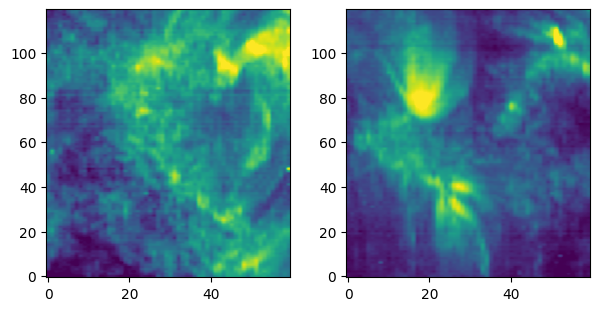

In [184]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(6,3), layout="constrained")

ax1.imshow(np.nansum(spice_NeVIII_data_bin_r1, axis=0), origin="lower",
           norm=ImageNormalize(vmin=np.nanpercentile(np.nansum(spice_NeVIII_data_bin_r1, axis=0), 0.5),
            vmax=np.nanpercentile(np.nansum(spice_NeVIII_data_bin_r1, axis=0), 99.5),
            stretch=AsinhStretch()), aspect=plot_aspect)

ax2.imshow(np.nansum(spice_NeVIII_data_bin_r2, axis=0), origin="lower",
           norm=ImageNormalize(vmin=np.nanpercentile(np.nansum(spice_NeVIII_data_bin_r2, axis=0), 0.5),
            vmax=np.nanpercentile(np.nansum(spice_NeVIII_data_bin_r2, axis=0), 99.5),
            stretch=AsinhStretch()), aspect=plot_aspect)

In [141]:
# exponent index of PSF exp(-x**(2*expo))
# 1 means Gaussian
# greater than 1 means the wing decreases more rapidly  

yl_core_xpo = 1.8

yl_wing_xpo = 1

# Rotation angle of the PSF, both core and wings
psf_yl_angle = -10*np.pi/180

# FWHMs of PSF core. First argument is width along y axis before rotation,
# and is in arcseconds. Second is along lambda axis and is in angstrom.
fwhm_core0_yl = np.array([1.5, 1.11])

# This descriptor for plots should be manually edited to reflect the PSF parameters
gaussian_desc = '2-part Gaussian PSF'

fwhm_wing0_yl = np.array([8.0, 4.5]) # FWHMs of PSF wings in arcseconds and angstroms, respectively
desc_str='; standard wing aspect ratio'

# Fraction of overall PSF amplitude in wings (core weight is 1.0 - wing_weight).
# PSFs have unit peak amplitude, -- PLEASE NOTE: they do not integrate to 1.
wing_weight = 0.28

In [142]:
spice_NeVIII_corr_data_r1, spice_NeVIII_cor_chi2s_r1, metadict_r1 = \
    correct_spice_raster(spice_NeVIII_data_bin_r1.transpose([2,1,0]), spice_NeVIII_header, fwhm_core0_yl, fwhm_wing0_yl, 
                        psf_yl_angle, wing_weight, yl_core_xpo=yl_core_xpo,
                        yl_wing_xpo=yl_wing_xpo,
                        super_fac=1, chi2_th = 0.5,
                        psf_thold_core=0.0005, spice_bin_facs = rebin_facs)
                        
spice_NeVIII_corr_data_r1 = spice_NeVIII_corr_data_r1.transpose([2,1,0])

Correcting Ne VIII 770 - Peak; ref. wavelength=768.1242035
Computing PSF Core:
4.980204209210252 % done after 0.36953139305114746 seconds
9.98124609293603 % done after 0.738633394241333 seconds
14.982287976661805 % done after 1.1116182804107666 seconds
19.98332986038758 % done after 1.479959487915039 seconds
24.984371744113357 % done after 1.847942590713501 seconds
29.985413627839133 % done after 2.2154324054718018 seconds
34.98645551156491 % done after 2.5811119079589844 seconds
39.98749739529069 % done after 2.947373867034912 seconds
44.988539279016464 % done after 3.3150062561035156 seconds
49.98958116274224 % done after 3.6808571815490723 seconds
54.990623046468016 % done after 4.047224760055542 seconds
59.99166493019379 % done after 4.414740324020386 seconds
64.99270681391957 % done after 4.780521631240845 seconds
69.99374869764534 % done after 5.146515130996704 seconds
74.99479058137112 % done after 5.512382745742798 seconds
79.9958324650969 % done after 5.882283449172974 seconds

KeyboardInterrupt: 

In [ ]:
spice_NeVIII_corr_data_r2, spice_NeVIII_cor_chi2s_r2, metadict_r2 = \
    correct_spice_raster(spice_NeVIII_data_bin_r2.transpose([2,1,0]), spice_NeVIII_header, fwhm_core0_yl, fwhm_wing0_yl, 
                        psf_yl_angle, wing_weight, yl_core_xpo=yl_core_xpo,
                        yl_wing_xpo=yl_wing_xpo,
                        super_fac=1, chi2_th = 0.5,
                        psf_thold_core=0.0005, spice_bin_facs = rebin_facs)
                        
spice_NeVIII_corr_data_r2 = spice_NeVIII_corr_data_r2.transpose([2,1,0])

Correcting Ne VIII 770 - Peak; ref. wavelength=767.6366184999999
Computing PSF Core:
4.98416402733789 % done after 0.4621109962463379 seconds
9.984997499583264 % done after 0.92226243019104 seconds
14.985830971828639 % done after 1.3821852207183838 seconds
19.986664444074012 % done after 1.8415555953979492 seconds
24.987497916319388 % done after 2.301849842071533 seconds
29.98833138856476 % done after 2.765115737915039 seconds
34.989164860810135 % done after 3.2253410816192627 seconds
39.98999833305551 % done after 3.686706304550171 seconds
44.990831805300886 % done after 4.1478776931762695 seconds
49.99166527754626 % done after 4.609342336654663 seconds
54.99249874979163 % done after 5.070033073425293 seconds
59.993332222037004 % done after 5.530548572540283 seconds
64.99416569428239 % done after 5.991538047790527 seconds
69.99499916652775 % done after 6.451728343963623 seconds
74.99583263877312 % done after 6.912540912628174 seconds
79.9966661110185 % done after 7.372741937637329 sec

In [ ]:
def func_NeVIII_770_sg(x, wvl_770, int_770, wid_770, a, b):
    return gaussian(x, wvl_770, int_770, wid_770) + \
           a*x + b

In [194]:
def work_fit_single_spec(args):
    (NeVIII_770_wvl, NeVIII_770_data_rebin,
    NeVIII_770_window_start, NeVIII_window_end,
    ii, jj) = args
    
    try:
        data_slice = NeVIII_770_data_rebin[NeVIII_770_window_start[ii,jj]:NeVIII_window_end[ii,jj]+1,
                                           ii, jj]
        
        p0 = [
            NeVIII_770_wvl[np.nanargmax(data_slice)],  # wavelength of max
            np.nanmax(data_slice),  # intensity 
            0.8,  # width
            0,  # linear term a
            0   # linear term b
        ]
        
        # Bounds for parameters
        bounds = (
            (0, 0, 0, -np.inf, -np.inf),
            (np.inf, np.inf, np.inf, np.inf, np.inf)
        )
        
        # Perform curve fitting
        popt, pcov = curve_fit(
            func_NeVIII_770_sg,
            NeVIII_770_wvl[NeVIII_770_window_start[ii,jj]:NeVIII_window_end[ii,jj]+1],
            data_slice,
            p0=p0,
            bounds=bounds,
            nan_policy="omit"
        )
        
        # Return position and fitted parameters
        return (ii, jj, popt)
    
    except Exception as e:
        # Return None or a special marker for failed fits
        return (ii, jj, None)


In [195]:
def fit_parallel(NeVIII_770_wvl, NeVIII_770_data_rebin, NeVIII_770_window_start=spice_NeVIII_window_start,
                 NeVIII_770_window_end=spice_NeVIII_window_end, ncpu=8):
    # Prepare input arguments for each position
    input_args = [
        (NeVIII_770_wvl, NeVIII_770_data_rebin,
         NeVIII_770_window_start, NeVIII_770_window_end,
         ii, jj) 
        for ii in range(NeVIII_770_data_rebin.shape[1]) 
        for jj in range(NeVIII_770_data_rebin.shape[2])
    ]
    
    # Prepare result arrays
    shape = NeVIII_770_data_rebin.shape[1:]
    NeVIII_fit_wvl = np.zeros(shape)
    NeVIII_fit_int = np.zeros(shape)
    NeVIII_fit_wid = np.zeros(shape)
    NeVIII_fit_a = np.zeros(shape)
    NeVIII_fit_b = np.zeros(shape)
    
    # Use ProcessPoolExecutor to parallelize fitting
    with ProcessPoolExecutor(max_workers=ncpu) as executor:
        # Submit all tasks
        futures = [executor.submit(work_fit_single_spec, args) for args in input_args]
        
        # Process results as they complete
        for future in concurrent.futures.as_completed(futures):
            result = future.result()
            
            # Check if fitting was successful
            if result[2] is not None:
                ii, jj, popt = result
                
                # Store results in respective arrays
                NeVIII_fit_wvl[ii, jj] = popt[0]
                NeVIII_fit_int[ii, jj] = popt[1]
                NeVIII_fit_wid[ii, jj] = popt[2]
                NeVIII_fit_a[ii, jj] = popt[3]
                NeVIII_fit_b[ii, jj] = popt[4]
    
    return (
        NeVIII_fit_wvl, 
        NeVIII_fit_int, 
        NeVIII_fit_wid, 
        NeVIII_fit_a, 
        NeVIII_fit_b
    )

In [197]:
(NeVIII_orig_fit_wvl_r1, NeVIII_orig_fit_int_r1, NeVIII_orig_fit_wid_r1,
                NeVIII_orig_fit_a_r1, NeVIII_orig_fit_b_r1) = fit_parallel(spice_NeVIII_wvl,
                                                                           spice_NeVIII_data_bin_r1)

In [206]:
# exponent index of PSF exp(-x**(2*expo))
# 1 means Gaussian
# greater than 1 means the wing decreases more rapidly  

yl_core_xpo = 1.8

yl_wing_xpo = 1

# Rotation angle of the PSF, both core and wings
psf_yl_angle = -13*np.pi/180

# FWHMs of PSF core. First argument is width along y axis before rotation,
# and is in arcseconds. Second is along lambda axis and is in angstrom.
fwhm_core0_yl = np.array([1.8, 1.11])

# This descriptor for plots should be manually edited to reflect the PSF parameters
gaussian_desc = '2-part Gaussian PSF'

fwhm_wing0_yl = np.array([10.0, 4.5]) # FWHMs of PSF wings in arcseconds and angstroms, respectively
desc_str='; standard wing aspect ratio'

# Fraction of overall PSF amplitude in wings (core weight is 1.0 - wing_weight).
# PSFs have unit peak amplitude, -- PLEASE NOTE: they do not integrate to 1.
wing_weight = 0.28


spice_NeVIII_corr_data_r1, spice_NeVIII_cor_chi2s_r1, metadict_r1 = \
    correct_spice_raster(spice_NeVIII_data_bin_r1.transpose([2,1,0]), spice_NeVIII_header, fwhm_core0_yl, fwhm_wing0_yl, 
                        psf_yl_angle, wing_weight, yl_core_xpo=yl_core_xpo,
                        yl_wing_xpo=yl_wing_xpo,
                        super_fac=1, chi2_th = 0.5,
                        psf_thold_core=0.0005, spice_bin_facs = rebin_facs)
                        
spice_NeVIII_corr_data_r1 = spice_NeVIII_corr_data_r1.transpose([2,1,0])

Correcting Ne VIII 770 - Peak; ref. wavelength=768.1242035
Computing PSF Core:
4.980204209210252 % done after 0.39968228340148926 seconds
9.98124609293603 % done after 0.7955543994903564 seconds
14.982287976661805 % done after 1.1901006698608398 seconds
19.98332986038758 % done after 1.5846459865570068 seconds
24.984371744113357 % done after 1.9799182415008545 seconds
29.985413627839133 % done after 2.374584197998047 seconds
34.98645551156491 % done after 2.7697107791900635 seconds
39.98749739529069 % done after 3.164243459701538 seconds
44.988539279016464 % done after 3.5591628551483154 seconds
49.98958116274224 % done after 3.954702854156494 seconds
54.990623046468016 % done after 4.349174976348877 seconds
59.99166493019379 % done after 4.744367837905884 seconds
64.99270681391957 % done after 5.139347076416016 seconds
69.99374869764534 % done after 5.533678770065308 seconds
74.99479058137112 % done after 5.928536415100098 seconds
79.9958324650969 % done after 6.322882652282715 second

In [207]:
(NeVIII_corr_fit_wvl_r1, NeVIII_corr_fit_int_r1, NeVIII_corr_fit_wid_r1,
                NeVIII_corr_fit_a_r1, NeVIII_corr_fit_b_r1) = fit_parallel(spice_NeVIII_wvl,
                                                                           spice_NeVIII_corr_data_r1)

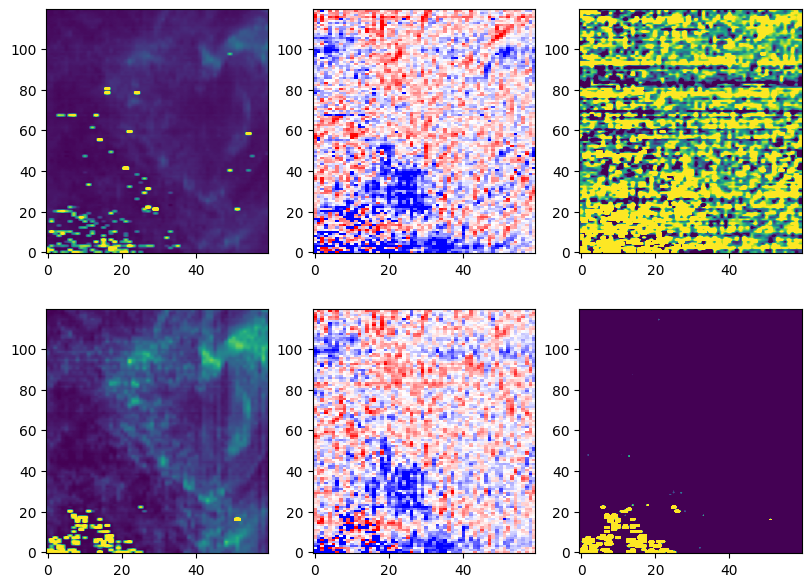

In [208]:
fig, ((ax1,ax2,ax3), (ax4,ax5,ax6)) = plt.subplots(2,3,figsize=(8,6), layout="constrained")

ax1.imshow(NeVIII_orig_fit_int_r1, origin="lower",
            norm=ImageNormalize(vmin=np.nanpercentile(NeVIII_orig_fit_int_r1, 0.1),
                                vmax=np.nanpercentile(NeVIII_orig_fit_int_r1, 99.5),
                                stretch=AsinhStretch(0.1)), aspect=plot_aspect)

ax2.imshow((NeVIII_orig_fit_wvl_r1 - np.nanmedian(NeVIII_orig_fit_wvl_r1, axis=0)[np.newaxis,:])/770*3e5,
            norm=ImageNormalize(vmin=-40, vmax=40), cmap="bwr", origin="lower",
            aspect=plot_aspect, interpolation='none')

ax3.imshow(NeVIII_orig_fit_wid_r1, norm=ImageNormalize(vmin=0.8, vmax=0.9),
            origin="lower", aspect=plot_aspect)

ax4.imshow(NeVIII_corr_fit_int_r1, origin="lower",
            norm=ImageNormalize(vmin=np.nanpercentile(NeVIII_corr_fit_int_r1, 2),
                                vmax=np.nanpercentile(NeVIII_corr_fit_int_r1, 99),
                                stretch=AsinhStretch(0.1)), aspect=plot_aspect)

ax5.imshow((NeVIII_corr_fit_wvl_r1 - np.nanmedian(NeVIII_corr_fit_wvl_r1, axis=0)[np.newaxis,:])/770*3e5,
            norm=ImageNormalize(vmin=-40, vmax=40), cmap="bwr", origin="lower",
            aspect=plot_aspect, interpolation='none')

ax6.imshow(NeVIII_corr_fit_wid_r1, norm=ImageNormalize(vmin=0.8, vmax=0.9),
            origin="lower", aspect=plot_aspect)

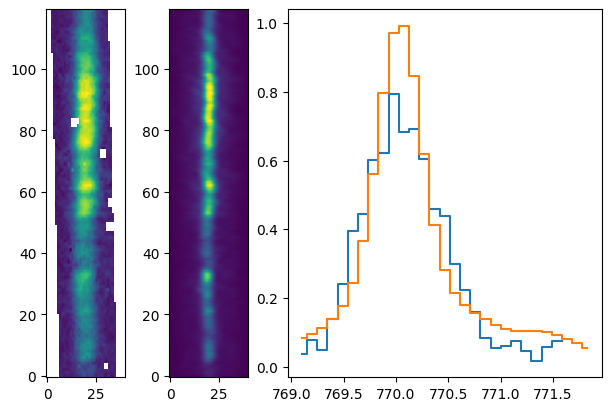

In [209]:
select_index = 40, 20
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(6,4), layout="constrained",
                                gridspec_kw={"width_ratios":[1,1,4]})

ax1.imshow(spice_NeVIII_data_bin_r1[:, :, select_index[1]].T, origin="lower", aspect="auto", 
           norm=ImageNormalize(vmin=np.nanpercentile(spice_NeVIII_data_bin_r1[:, :, select_index[1]],0.1),
                               vmax=np.nanpercentile(spice_NeVIII_data_bin_r1[:, :, select_index[1]],99.9),
                               stretch=AsinhStretch(0.4)))

ax2.imshow(spice_NeVIII_corr_data_r1[:, :, select_index[1]].T, origin="lower", aspect="auto", 
           norm=ImageNormalize(vmin=np.nanpercentile(spice_NeVIII_corr_data_r1[:, :, select_index[1]],0.1),
                               vmax=np.nanpercentile(spice_NeVIII_corr_data_r1[:, :, select_index[1]],99.9),
                               stretch=AsinhStretch(0.4)))

ax3.step(spice_NeVIII_wvl[spice_NeVIII_window_start[*select_index]:spice_NeVIII_window_end[*select_index]],
         spice_NeVIII_data_bin_r1[spice_NeVIII_window_start[*select_index]:spice_NeVIII_window_end[*select_index], *select_index], where="mid")
ax3.step(spice_NeVIII_wvl[spice_NeVIII_window_start[*select_index]:spice_NeVIII_window_end[*select_index]],
         spice_NeVIII_corr_data_r1[spice_NeVIII_window_start[*select_index]:spice_NeVIII_window_end[*select_index], *select_index], where="mid")

In [210]:
spice_NeVIII_data_bin_r1.shape

(40, 120, 60)